# Earth Energy Balance Model

This notebook investigates equilibrium solutions of a nonlinear Earth energy balance model (EBM) using a pseudo-arclength numerical continuation and stability analysis methods. The model describes the balance between absorbed solar radiation, emitted thermal radiation, and diffusive heat redistribution across the Earth. Latitude $\theta$ is rewritten to a coordinate $x = \sin{\theta}$ (dimensionless), such that $x \in [-1,1]$ from pole to pole.

The temperature distribution $T(t,x)$ satisfies

$$
R_A - R_E + R_D = C_T \frac{\partial T}{\partial t},
$$

where:
- $R_A$ represents absorbed solar radiation,
- $R_E$ represents emitted thermal radiation,
- $R_D$ models diffusive heat transport.

The absorbed radiation is given by

$$
R_A = Q(x)(1-\alpha(T(x))) + \mu,
$$

where $Q(x)$ is the solar radiation, $\mu$ is a greenhouse forcing parameter and $\alpha(T)$ is a temperature-dependent albedo function describing transitions between ice-covered and ice-free regions. Here, the functions $Q(x)$ and $\alpha(T)$ are defined as

$$
Q(x) = Q_0 (1-0.241(3x^2-1)),
$$

$$
\alpha(T) = \alpha_1 - \frac{1}{2}(\alpha_2 - \alpha_1)(1+\tanh(M(T-T_{*}))).
$$

Thermal radiation is modeled by

$$
R_E = \varepsilon_0 \sigma_0 T^4,
$$

while diffusive heat transport is modeled as

$$
R_D =
\frac{\partial}{\partial x}
\left(D(1-x^2)\frac{\partial T}{\partial x}
\right).
$$

We focus on equilibrium solutions of the EBM. Therefore, we consider steady-state solutions satisfying

$$
\frac{\partial T}{\partial t}=0.
$$

To discretize the spatial dimension, a truncated Legendre eigenfunction expansion is employed:

$$
T(\mathbf{a},x)
\approx
\sum_{n=0}^{N} a_n P_n(x),
$$

where $P_n(x)$ are Legendre polynomials and $\mathbf{a}$ contains the expansion coefficients. Applying a Galerkin projection results in a nonlinear algebraic system with $N+1$ unknown coefficients.

To study the equilibrium structure of the EBM, pseudo-arclength continuation is applied in the greenhouse forcing parameter $\mu$, ranging from $0$ to $100$. This allows the computation of equilibrium branches and bifurcation diagrams, including unstable solution branches.

The continuation method uses an initial arclength step size

$$
\Delta s = 0.1,
$$

which is dynamically adapted depending on the convergence behavior of the root-finding method. The minimum and maximum continuation step sizes are chosen as

$$
\Delta s_{\min}=0.01,
\qquad
\Delta s_{\max}=0.5.
$$

The nonlinear algebraic system is solved using the Newton-Raphson method. A maximum of 500 Newton iterations is used, and convergence is reached when

$$
||\mathbf{F}(\mathbf{a}^k)||_{\infty} \leq 10^{-6}.
$$

Throughout the experiments, we use $N=10$.

The resulting bifurcation diagram is analyzed together with the extent of ice coverage on the planet. A location is considered ice-covered when the temperature satisfies

$$
T < T_* = 272 \text{ K}.
$$

## Running the Experiments

Run all cells sequentially to reproduce the bifurcation diagram.

### Importing libraries

In [1]:
import numpy as np
import scipy.special as ss
from scipy import integrate
import scipy.linalg as sl
from copy import copy
import matplotlib.pyplot as plt

### Defining the parameters

In [2]:
Q0 = 341.3
alpha1 = 0.7
alpha2 = 0.289
eps = 0.61
sigma = 5.67e-8
M = 0.1
D = 0.3
mu = 30
CT = 5e8
Tstar = 272

### Defining the functions

In [3]:
def Q(x: float) -> float:
    """
    The solar radiation function.

    Parameters:
        x (float): x value.

    Returns:
        Q(x) (float): value of Q(x).
    """
    return Q0*(1-0.241*(3*x**2-1))

def Alpha(Tbar: float) -> float:
    """
    The albedo function.

    Parameters:
        Tbar (float): value of T(x).
    
    Returns:
        Alpha(Tbar) (float): value of Alpha(Tbar).
    """
    return alpha1+0.5*(alpha2-alpha1)*(1+np.tanh(M*(Tbar-Tstar)))

def AlphaDerivative(Tbar):
    """
    The albedo derivative function.

    Parameters:
        Tbar (float): value of T(x).
    
    Returns:
        AlphaDerivative(Tbar) (float): value of derivative of Alpha(Tbar).
    """
    return 0.5*(alpha2-alpha1)*M*(1-np.tanh(M*(Tbar-Tstar))**2)

def T(a: np.ndarray, x: float) -> float:
    """
    The truncated eigenfunction expansion of T(x).

    Parameters:
        a (np.ndarray): the expansion coefficients.
        x (float): x value.

    Returns:
        T(x) (float): truncated eigenfunction expansion.
    """
    res = 0
    for i, elt in enumerate(a):
        res += elt*ss.eval_legendre(i,x)
    return res

def RA(a: np.ndarray, x: float, mu: float) -> float:
    """
    The absorbed solar radiation term RA.

    Parameters:
        a (np.ndarray): the expansion coefficients.
        x (float): x value.
        mu (float): mu value.

    Returns:
        RA (float): absorbed solar radiation term RA.
    """
    return Q(x)*(1-Alpha(T(a,x))) + mu

def RE(a,x):
    """
    The emitted radiation term RE.

    Parameters:
        a (np.ndarray): the expansion coefficients.
        x (float): x value.

    Returns:
        RE (float): emitted radiation term RE.
    """
    return eps*sigma*T(a,x)**4

def IntegralTerm(x: float, m: int, a: np.ndarray, mu: float) -> float:
    """
    The integral term after applying an eigenfunction expansion.

    Parameters:
        x (float): x value.
        m (int): the Legendre mode index.
        a (np.ndarray): the expansion coefficients.
        mu (float): mu value.

    Returns:
        IntegralTerm (float): the integral term of equation m after applying an eigenfunction expansion.
    """
    return ss.eval_legendre(m,x) * (RA(a,x,mu) - RE(a,x))

def IntegralTermJacobianExact(x: float, m: int, l: int, a: np.ndarray) -> float:
    """
    The derivative of the integral term after applying an eigenfunction expansion for the Jacobian matrix.

    Parameters:
        x (float): x value.
        m (int): the Legendre mode index.
        l (int): coefficient index.
        a (np.ndarray): the expansion coefficients.

    Returns:
        IntegralTermDerivative (float): the integral term derivative of equation m
                                        with respect to index l after applying an eigenfunction expansion.
    """
    return ss.eval_legendre(m,x)*ss.eval_legendre(l,x) * (-Q(x)*AlphaDerivative(T(a,x)) - 4*eps*sigma*T(a,x)**3)

### Defining the nonlinear system and Jacobian

In [4]:
def nonlinear_system(a: np.ndarray, N: int, mu: float = 30) -> np.ndarray:
    """
    The nonlinear system after applying an eigenfunction expansion.

    Parameters:
        a (np.ndarray): the expansion coefficients.
        N (int): number of unknowns + 1.
        mu (float): mu value. Set standard to 30.

    Returns:
        nonlinear_system (np.ndarray): the nonlinear system.
    """
    n = 50
    system = np.zeros(N+1)
    for m in range(N+1):
        integral = float(integrate.fixed_quad(IntegralTerm, -1, 1, n = n, args = (m,a,mu))[0])
        Lambda = D*m*(m+1)
        system[m] = integral - a[m]*Lambda*2/(2*m+1)
    return system

def ExactJacobian(a: np.ndarray, N: int) -> np.ndarray:
    """
    The Jacobian of the nonlinear system after applying an eigenfunction expansion.

    Parameters:
        a (np.ndarray): the expansion coefficients.
        N (int): number of unknowns + 1.

    Returns:
        Jacobian (np.ndarray): the Jacobian of the nonlinear system.
    """
    n = 50
    J = np.zeros((N+1,N+1))
    for m in range(N+1):
        for l in range(N+1):
            extra_term = 0
            integral = float(integrate.fixed_quad(IntegralTermJacobianExact, -1, 1, n = n, args = (m,l,a))[0])
            if m == l:
                Lambda = D*m*(m+1)
                extra_term = Lambda*2/(2*m+1)
            J[m,l] = integral - extra_term
    return J

### Defining the root finding method

In [5]:
def NewtonRaphson(a0: np.ndarray, N: int, max_iter: int = 500, tol: float = 1e-6, mu: float = 30) -> tuple[np.ndarray, int]:
    """
    The Newton-Raphson rootfinding method.

    Parameters:
        a0 (np.ndarray): the initial guess.
        N (int): number of unknowns + 1.
        max_iter (int): maximum number of iterations. Set standard to 500.
        tol (float): stopping tolerance. Set standard to 1e-6.
        mu (float): mu value. Set standard to 30.

    Returns:
        a_root (np.ndarray), iter (int): The root and the number of iterations needed.
    """
    a_old = a0.copy()
    F = nonlinear_system(a_old,N,mu)
    eps = np.max(np.abs(F))
    iter = 0
    #print(eps)
    while eps > tol and iter < max_iter:
        J = ExactJacobian(a_old,N)
        s = sl.solve(J,-F)
        a_new = a_old + s
        F = nonlinear_system(a_new,N,mu)
        eps = np.max(np.abs(F))
        a_old = a_new.copy()
        iter += 1
    return a_old, iter

### Solving the system for $\mu = 30$ using initial condition $\mathbf{a}_0 = [1,1,\dots,1]$

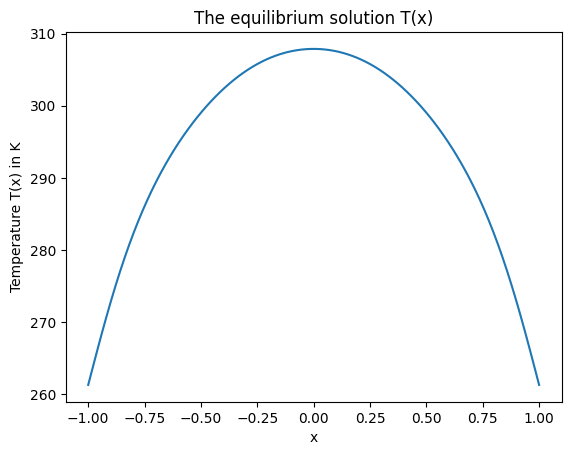

The vector a is defined as = [ 2.94517164e+02 -5.88745461e-15 -2.92038322e+01  2.18441658e-15
 -3.82885886e+00 -2.31727073e-15 -5.87478467e-01  1.68868603e-15
  2.13234474e-01  2.64532025e-15  2.03708220e-01]


In [6]:
#Number of unknowns + 1
N = 10
max_iter = 500
tol = 1e-6
a0 = np.ones(N+1)
a, iter = NewtonRaphson(a0, N, tol = tol, max_iter = max_iter)

x = np.linspace(-1,1,100)
plt.plot(x,T(a,x))
plt.xlabel('x')
plt.ylabel('Temperature T(x) in K')
plt.title('The equilibrium solution T(x)')
plt.show()

print("The vector a is defined as =", a)

### The continuation process

In [7]:
mu0 = 0
Nopt = 6
Deltas = 0.1
N = 10
a0 = np.ones(N+1)
Deltas_min = 0.01
Deltas_max = 0.5

v0 = np.ones(N+2)

def Jacobian_mu_integral(x: float, m: int) -> float:
    """
    The derivatives of the nonlinear system with respect to the mu parameter.

    Parameters:
        x (float): x value.
        m (int): the Legendre mode index.
    
    Returns:
        Jacobian_mu (float): The derivative of the nonlinear system with respect to the mu parameter.
    """
    return ss.eval_legendre(m,x)

#This is constant in mu
Jacobian_mu = np.zeros(N+1)
for i in range(N+1):
    Jacobian_mu[i] += float(integrate.fixed_quad(Jacobian_mu_integral, -1, 1, n = 50, args = (i,))[0])

def predictor(Deltas: float , v: np.ndarray, N: int, a_prev: np.ndarray, mu_prev: float) -> tuple[np.ndarray, float, np.ndarray]:
    """
    The predictor step in the continuation process.

    Parameters:
        Deltas (float): continuation step size.
        v (np.ndarray): extra continuation equation.
        N (int): number of unknowns + 2.
        a_prev (np.ndarray): the equilibrium solution of the previous step.
        mu_prev (float); the equilibrium solution of the previous step.

    Returns:
        a_pred (np.ndarray), mu_pred (float), z (np.ndarray): the prediction of the current step and the tangent vector.
    """ 
    # Computing the tangent line
    A = np.zeros((N+2,N+2))
    A[:-1,:-1] = ExactJacobian(a_prev,N)
    A[:-1,-1] = Jacobian_mu

    # Extra equation
    A[-1,:] = v

    RHS = np.zeros((N+2))
    RHS[-1] = 1

    z = np.linalg.solve(A, RHS)

    #Normalize
    norm = np.sqrt(np.sum(z[:-1]**2) + z[-1]**2)

    #Predictor step
    a_pred = a_prev + Deltas*z[:-1]  / norm
    mu_pred = mu_prev + Deltas*z[-1] / norm

    return a_pred, mu_pred, z 

def nonlinear_system_bifurcation(N: int, Deltas: float, a_prev: np.ndarray, mu_prev: float, a: np.ndarray, mu: float, z: np.ndarray) -> np.ndarray:
    """
    The nonlinear system after applying an eigenfunction expansion with mu as extra variable.

    Parameters:
        N (int): number of unknowns + 2.
        Deltas (float): continuation step size.
        a_prev (np.ndarray): the equilibrium solution of the previous step.
        mu_prev (float); the equilibrium solution of the previous step.
        a (np.ndarray): current expansion coefficients.
        mu (float): current mu.
        z (np.ndarray): the tangent vector.

    Returns:
        nonlinear_system (np.ndarray): the nonlinear system with mu as extra variable.
    """
    system = np.zeros(N+2)
    system[:-1] = nonlinear_system(a=a,N=N,mu=mu)
    system[-1] = 1*np.sum(z[:-1]*(a - a_prev)) + z[-1]*(mu-mu_prev) - Deltas
    return system

def Jacobian_Bifurcation(N: int, a_prev: np.ndarray, mu_prev: float, a: np.ndarray, mu: float, z: np.ndarray) -> np.ndarray:
    """
    The Jacobian of the nonlinear system after applying an eigenfunction expansion with mu as extra variable.

    Parameters:
        N (int): number of unknowns + 2.
        a_prev (np.ndarray): the equilibrium solution of the previous step.
        mu_prev (float); the equilibrium solution of the previous step.
        a (np.ndarray): current expansion coefficients.
        mu (float): current mu.
        z (np.ndarray): the tangent vector.

    Returns:
        Jacobian (np.ndarray): the Jacobian of the nonlinear system with mu as extra variable.
    """
    J = np.zeros((N+2,N+2))
    J[:-1,:-1] = ExactJacobian(a=a,N=N)
    J[:-1,-1] = Jacobian_mu

    for i in range(N+1):
        J[-1,i] = z[i]
    J[-1,-1] = z[-1]
    return J

def NewtonRaphson_Bifurcation(initial: np.ndarray, N: int, Deltas: float, a_prev: np.ndarray, mu_prev: float,
                            z: np.ndarray, max_iter: int = 500, tol: float = 1e-6) -> tuple[np.ndarray, int]:
    """
    The Newton-Raphson rootfinding method for the system with mu as variable.

    Parameters:
        initial (np.ndarray): the initial guess.
        N (int): number of unknowns + 2.
        Deltas (float): continuation step size.
        a_prev (np.ndarray): the equilibrium solution of the previous step.
        mu_prev (float); the equilibrium solution of the previous step.
        z (np.ndarray): the tangent vector.
        max_iter (int): maximum number of iterations. Set standard to 500.
        tol (float): stopping tolerance. Set standard to 1e-6.

    Returns:
        root (np.ndarray), iter (int): The root and the number of iterations needed.
    """
    old = initial.copy()
    F = nonlinear_system_bifurcation(N, Deltas, a_prev, mu_prev, initial[:-1], initial[-1], z)
    eps = np.max(np.abs(F))
    iter = 0
    while eps > tol and iter < max_iter:
        J = Jacobian_Bifurcation(N, a_prev, mu_prev, old[:-1], old[-1], z)
        s = sl.solve(J,-F)
        new = old + s
        F = nonlinear_system_bifurcation(N, Deltas, a_prev, mu_prev, new[:-1], new[-1], z)
        eps = np.max(np.abs(F))
        old = new.copy()
        iter += 1
    return old, iter

def corrector(Deltas, a_pred, mu_pred, a_prev, mu_prev, z):
    """
    The corrector step in the continuation process.

    Parameters:
        Deltas (float): continuation step size.
        a_pred (np.ndarray): the prediction of the current step.
        mu_pred (float): the prediction of the current step.
        a_prev (np.ndarray): the equilibrium solution of the previous step.
        mu_prev (float): the equilibrium solution of the previous step.
        z (np.ndarray): the tangent vector.

    Returns:
        root (np.ndarray), iter (int): The root and the number of iterations needed.
    """ 
    initial = np.zeros(N+2)
    initial[:-1] = a_pred
    initial[-1] = mu_pred
    return NewtonRaphson_Bifurcation(initial, N, Deltas, a_prev, mu_prev, z)

def stability_check(a: np.ndarray, N: int) -> int:
    """
    Checking the stability of the equilibrium solution.

    Parameters:
        a (np.ndarray): the coefficients of the equilibrium solution.
        N (int): the number of unknowns + 1.

    Returns:
        stability (int), real_eig (float): the stability, where 0 is stable and -1 is unstable.
    """
    J = ExactJacobian(a,N)
    eig, vec = np.linalg.eig(J)
    if len(np.where(np.real(eig) > 0)[0]) > 0:
        return -1
    return 0

def continuation(a0: np.ndarray, v0: np.ndarray, N: int, Deltas: float, mu0: float, Nopt: int) -> np.ndarray:
    """
    The continuation process.

    Parameters:
        a0 (np.ndarray): the initial guess when mu = mu0.
        v0 (np.ndarray): the initial extra continuation equation.
        N (int): number of unknowns + 2.
        Deltas (float): continuation step size.
        m0 (float): the starting point of the continuation.
        Nopt (float): the optimal number of iterations needed for Newton-Raphson per continuation step.

    Returns:
        res (np.ndarray): the continuation steps.
    """ 
    res = []

    #Initial start
    mu_prev = mu0
    a_prev, _ = NewtonRaphson(a0, N,mu=mu_prev)
    v = v0.copy()

    stability = stability_check(a_prev, N)

    step = []
    for j in range(N+1):
        step.append(a_prev[j])
    step.append(mu_prev)
    step.append(stability)
    res.append(step)

    while mu_prev < 100:
        a_pred, mu_pred, z = predictor(Deltas, v, N, a_prev, mu_prev)
        new, iter = corrector(Deltas, a_pred, mu_pred, a_prev, mu_prev, z)

        if iter == 0:
            xi_bar = 2
        else:
            xi_bar = Nopt/iter

        if xi_bar > 2:
            xi_step = 2
        elif xi_bar < 0.5:
            xi_step = 0.5
        else:
            xi_step = xi_bar

        # Add minimum and maximum step size bounds
        Deltas = np.clip(Deltas * xi_step, Deltas_min, Deltas_max)

        # After corrector
        a_prev = new[:-1].copy()
        mu_prev = new[-1]

        v = z.copy()

        stability = stability_check(a_prev, N)

        step = []
        for j in range(N+1):
            step.append(a_prev[j])
        step.append(mu_prev)

        #Computing the ice coverage
        if stability != -1:
            x = np.linspace(-1,1,100)
            equilibrium = T(a_prev, x)
            if len(np.where(equilibrium >= Tstar)[0]) == len(x):
                
                stability = 2
            elif len(np.where(equilibrium >= Tstar)[0]) == 0:
                stability = 0
            else:
                stability = 1

        step.append(stability)
        res.append(step)

    return np.array(res)

res = continuation(a0,v0, N, Deltas, mu0, Nopt)

### Plotting the bifurcation diagram

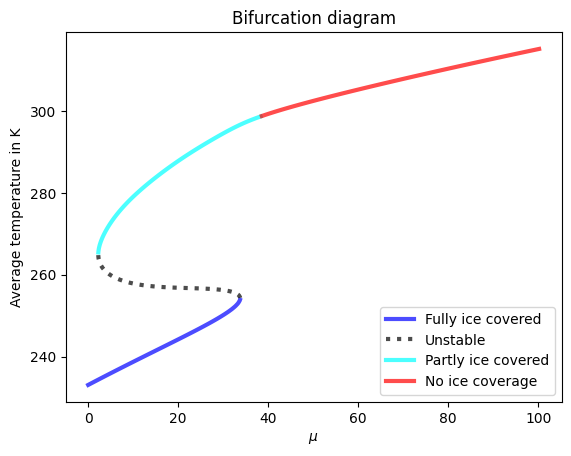

In [8]:
rest = np.array(res)
x = rest[:, -2]
y = rest[:, 0]
labels = rest[:, -1]

label_styles = {
    -1: {'color': 'black', 'linestyle': ':', 'label': 'Unstable', 'linewidth': 3},
     0: {'color': 'blue', 'linestyle': '-', 'label': 'Fully ice covered', 'linewidth': 3},
     1: {'color': 'cyan', 'linestyle': '-', 'label': 'Partly ice covered', 'linewidth': 3},
     2: {'color': 'red', 'linestyle': '-', 'label': 'No ice coverage', 'linewidth': 3}
}

i = 0
while i < len(x):
    current_label = labels[i]
    segment_x = [x[i]]
    segment_y = [y[i]]

    j = i + 1
    while j < len(x) and labels[j] == current_label:
        segment_x.append(x[j])
        segment_y.append(y[j])
        j += 1

    style = label_styles[current_label]

    plt.plot(segment_x, segment_y, color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth'], label=style['label'], alpha=0.7)

    i = j

plt.xlabel(r'$\mu$')
plt.ylabel('Average temperature in K')
plt.title(f'Bifurcation diagram')

handles, labels_legend = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
plt.legend(by_label.values(), by_label.keys())

plt.show()